# Installing Requirement, Setup

In [ ]:
!pip install -q transformers torch torchvision torchaudio
!pip install -q easyocr opencv-python pandas numpy
!pip install -q huggingface_hub ipywidgets rapidfuzz

In [ ]:
import os
import re
import cv2
import glob
import gc
import torch
import math
import numpy as np
import pandas as pd
import easyocr
from rapidfuzz import fuzz
from tqdm import tqdm
from collections import defaultdict

In [ ]:
image_folder = r"\super-ai-engineer-season-6-ocr-2569\data\images"
template_csv = r"\super-ai-engineer-season-6-ocr-2569\data\submission_template_v3.csv"
output_csv = r"\super-ai-engineer-season-6-ocr-2569\data\submission_v14.csv"
ocr_reader = easyocr.Reader(['th', 'en'], gpu=True)

In [ ]:
def extract_doc_id(file_name):
    name = file_name.replace('.png', '').replace('.jpg', '')
    if '_page' in name: return name.split('_page')[0]
    return name

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

# Text Cleaning & Rule-Based RegEX

In [ ]:
def extract_thai_checksum(full_text):
    text_str = re.sub(r'[0-9๐-๙]+', '', full_text)
    replacements = {
        "หมั่น": "หมื่น", "หมืน": "หมื่น", "กั้น": "พัน", "หนึง": "หนึ่ง", "หนงยมื่น": "หนึ่งหมื่น", "มื่น": "หมื่น",
        "สีพ้น": "สี่พัน", "หาลิบมิป": "หกสิบ", "ไตาร้อย": "หกร้อย", "ตาร้อย": "หกร้อย", "ทกร้อย": "หกร้อย", "ทกพัน": "หกพัน",
        "อีสิม": "ยี่สิบ", "อีสิบ": "ยี่สิบ", "ร้วย": "ร้อย", "ร้าย": "ร้อย", "เริ้อย": "ร้อย", "เร้อย": "ร้อย", "ร้อบ": "ร้อย", "ร่อย": "ร้อย",
        "สิสิบ": "สี่สิบ", "สีสิบ": "สี่สิบ", "สิร้อย": "สี่ร้อย", "สีร้อย": "สี่ร้อย", "สีพัน": "สี่พัน", "สิพัน": "สี่พัน",
        "สิม": "สิบ", "สิน": "สิบ", "ลิม": "สิบ", "ฮิม": "สิบ", "ลิบ": "สิบ", "ยีสิบ": "ยี่สิบ", "ยิสิบ": "ยี่สิบ",
        "เทมิ่ง": "หนึ่ง", "เทนึ่ง": "หนึ่ง", "ทนีง": "หนึ่ง", "ทนึ่ง": "หนึ่ง", "เหนึ่ง": "หนึ่ง",
        "ฮอง": "สอง", "สอ:": "สอง", "สอ.": "สอง", "ราม": "สาม", "ฮาม": "สาม", "สวม": "สาม", "สว่น": "สาม",
        "อี่": "สี่", "ฮี": "สี่", "สีทน": "สี่พัน", "เสี่": "สี่", "ท้า": "ห้า", "ทา": "ห้า", "หัวสิม": "ห้าสิบ",
        "ทถ": "หก", "ทก": "หก", "หว": "หก", "ทกสิบ": "หกสิบ", "ไทก": "หก", "หง": "หก",
        "เจด": "เจ็ด", "เช็ด": "เจ็ด", "แปอ": "แปด", "แปว": "แปด", "แปาร้อย": "แปดร้อย",
        "เถ้า": "เก้า", "เก้ว": "เก้า", "เว้า": "เก้า", "แไก้า": "เก้า", "แก้า": "เก้า", "เกว": "เก้า", "เอ็ด": "เอ็ด", "เอด": "เอ็ด",
        "ยสบ": "ยี่สิบ", "สสบ": "สี่สิบ", "สรอย": "สี่ร้อย", "สพน": "สี่พัน", "ทาสบ": "ห้าสิบ", "ทารอย": "ห้าร้อย", "ทาพน": "ห้าพัน",
        "ตกสบ": "หกสิบ", "ตกรอย": "หกร้อย", "ตกพน": "หกพัน"
    }
    for k, v in replacements.items(): text_str = text_str.replace(k, v)

    n_map = {"ศนย":0, "สน":0, "ศูนย์":0, "สูน":0, "หนง":1, "นง":1, "หนึ่ง":1, "หนึง":1, "หนี่ง":1, "นึง":1, "ไหนึ่ง":1, "ไหนง":1,
             "เอด":1, "เอ็ด":1, "เอีด":1, "เอ้ด":1, "สอง":2, "ส๒ง":2, "ยี่":2, "ยี":2, "ยิ":2, "สาม":3, "ส่าม":3,
             "สี่":4, "สี":4, "สิ่":4, "สื่":4, "ลี่":4, "ลี":4, "เสี่":4, "เส":4, "ห้า":5, "หา":5, "ห่า":5, "ท้า":5, "ห้าา":5, "ทา":5,
             "หก":6, "หด":6, "ทก":6, "เตก":6, "ตก":6, "เจ็ด":7, "เช็ด":7, "เจด":7, "เชด":7, "แปด":8, "ปด":8, "แปก":8, "เก้า":9, "เกา":9}
    p_map = {"สบ":10, "สิบ":10, "สืบ":10, "สิ่บ":10, "รอย":100, "ร้อย":100, "พน":1000, "พัน":1000, "พ้น":1000,
             "หมน":10000, "ทมน":10000, "หมื่น":10000, "หมืน":10000, "หมึน":10000, "ทมื่น":10000, "ทหมื่น":10000}

    keys = sorted(list(n_map.keys()) + list(p_map.keys()), key=len, reverse=True)
    found_words = re.findall(r'(' + '|'.join(keys) + r')', text_str)

    if not found_words: return "0"
    sum_val, curr_digit = 0, 0
    for w in found_words:
        if w in n_map: curr_digit = n_map[w]
        elif w in p_map:
            if curr_digit == 0 and p_map[w] == 10: curr_digit = 1
            sum_val += curr_digit * p_map[w]; curr_digit = 0
    sum_val += curr_digit
    return str(sum_val) if sum_val > 0 else "0"

In [ ]:
def extract_digits(text_str):
    text_str = text_str.replace("o", "0").replace("O", "0").replace("Q", "0").replace("อ", "0").replace("a", "0")
    text_str = text_str.replace("I", "1").replace("l", "1").replace("!", "1").replace("|", "1").replace("ด", "1").replace("เ", "1")
    text_str = text_str.replace("?", "7").replace("~", "").replace("ช", "").replace("ฉ", "").replace("ิ", "")
    text_str = text_str.replace(",", "").replace(".", "") # Comma Bug Fix

    t2a = str.maketrans('๐๑๒๓๔๕๖๗๘๙', '0123456789')
    arabic_text = text_str.translate(t2a)
    clean_text = re.sub(r'[^\d\s]', ' ', arabic_text)
    nums = clean_text.split()
    if nums:
        valid_nums = [n for n in nums if not re.match(r'^1{3,}$', n)]
        if valid_nums: return valid_nums[-1]
        return nums[-1]
    return "0"

In [ ]:
def clean_vote_string(row_full_text):
    if not row_full_text: return "0"
    text_str = extract_thai_checksum(row_full_text)
    digit_str = extract_digits(row_full_text)
    if text_str != "0": text_str = str(int(text_str))
    if digit_str != "0": digit_str = str(int(digit_str))
    if text_str == "0": return digit_str
    if digit_str == "0": return text_str
    if text_str == digit_str: return text_str
    if len(digit_str) >= len(text_str): return digit_str
    return text_str

# Deskew & Core OCR

In [ ]:
def get_deskew_angle(img_gray):
    h, w = img_gray.shape
    bin_inv = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5)
    kernel_len = w // 20
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))
    h_lines_only = cv2.morphologyEx(bin_inv, cv2.MORPH_OPEN, h_kernel)
    lines = cv2.HoughLinesP(h_lines_only, 1, np.pi/180, threshold=50, minLineLength=w//10, maxLineGap=20)
    angles = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 > x2: x1, y1, x2, y2 = x2, y2, x1, y1
            if x2 == x1:
              continue
            angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
            if -10 < angle < 10 and abs(angle) > 0.1: angles.append(angle)
    if len(angles) < 3:
      return 0.0
    return np.median(angles)

In [ ]:
def deskew_single_image(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    skew_angle = get_deskew_angle(gray)
    if abs(skew_angle) < 0.1:
      return img_bgr
    (h, w) = img_bgr.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, skew_angle, 1.0)
    return cv2.warpAffine(img_bgr, rotation_matrix, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))

## Example Deskewing

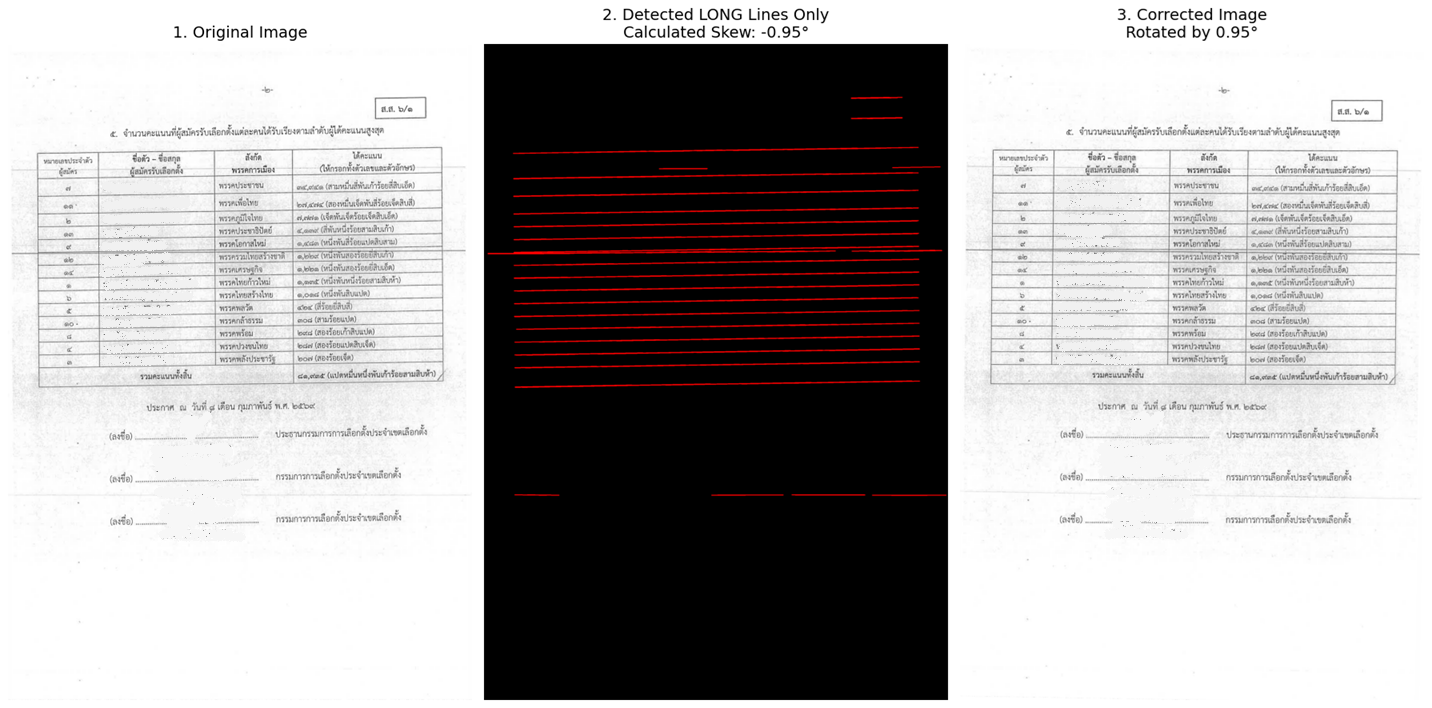

In [ ]:
def parse_image_data(paths):
    imgs = [deskew_single_image(cv2.imread(p)) for p in paths if cv2.imread(p) is not None]
    if not imgs: return {"data": [], "target_sum": 0}

    max_w = max([img.shape[1] for img in imgs])
    padded_imgs = [np.hstack((img, np.full((img.shape[0], max_w - img.shape[1], img.shape[2]), 255, dtype=np.uint8))) if img.shape[1] < max_w else img for img in imgs]
    merged_bgr = np.vstack(padded_imgs)
    merged_gray = cv2.cvtColor(merged_bgr, cv2.COLOR_BGR2GRAY)
    h, w = merged_gray.shape

    bin_img = cv2.adaptiveThreshold(merged_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 5)
    k_len = w // 100
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, k_len))
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k_len, 1))

    v_lines = cv2.dilate(cv2.erode(bin_img, v_kernel, iterations=2), v_kernel, iterations=2)
    h_lines = cv2.dilate(cv2.erode(bin_img, h_kernel, iterations=2), h_kernel, iterations=2)
    grid = cv2.add(v_lines, h_lines)
    points = cv2.findNonZero(grid)
    tx, ty, tw, th = cv2.boundingRect(points) if points is not None else (0, 0, w, h)
    tx, ty = max(0, tx - 10), max(0, ty - 10)
    tw, th = min(w - tx, tw + 20), min(h - ty, th + 20)

    text_only = cv2.subtract(bin_img, v_lines)
    text_only = cv2.subtract(text_only, h_lines)
    clean_text = cv2.morphologyEx(text_only, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))

    roi_h_lines = h_lines[ty:ty+th, tx:tx+tw]
    cnts_h, _ = cv2.findContours(roi_h_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    y_centers = sorted([ty + cv2.boundingRect(c)[1] + (cv2.boundingRect(c)[3] // 2) for c in cnts_h
                        if cv2.boundingRect(c)[2] > tw * 0.5])

    merged_y = []
    for y in y_centers:
        if not merged_y: merged_y.append(y)
        elif y - merged_y[-1] < 20: merged_y[-1] = (merged_y[-1] + y) // 2
        else: merged_y.append(y)

    if len(merged_y) < 3:
        merge_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w // 10, 5))
        text_blobs = cv2.dilate(clean_text, merge_kernel, iterations=2)
        cnts_text, _ = cv2.findContours(text_blobs, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        text_y_centers = sorted([ty + cv2.boundingRect(c)[1] + (cv2.boundingRect(c)[3] // 2) for c in cnts_text
                                 if cv2.boundingRect(c)[2] > tw * 0.1 and cv2.boundingRect(c)[3] > 10])
        text_rows = []
        for cy in text_y_centers:
            if not text_rows: text_rows.append(cy)
            elif cy - text_rows[-1] < 25: text_rows[-1] = (text_rows[-1] + cy) // 2
            else: text_rows.append(cy)
        merged_y = [ty] + [(text_rows[i] + text_rows[i+1]) // 2 for i in range(len(text_rows)-1)] + [ty + th]
    else:
        diffs = np.diff(merged_y)
        valid_diffs = [d for d in diffs if 30 < d < 120]
        if valid_diffs:
            std_h = np.median(valid_diffs)
            final_y = [merged_y[0]]
            for i in range(len(merged_y) - 1):
                y1, y2 = merged_y[i], merged_y[i+1]
                gap = y2 - y1
                if std_h * 1.5 < gap < std_h * 5.0:
                    num_missing = int(round(gap / std_h)) - 1
                    step = gap / (num_missing + 1)
                    for j in range(1, num_missing + 1):
                        proposed_y = int(y1 + j * step)
                        best_y, min_noise = proposed_y, float('inf')
                        for scan_y in range(proposed_y - 10, proposed_y + 11):
                            noise = cv2.countNonZero(clean_text[max(0, scan_y - 1) : min(h, scan_y + 1), tx:tx+tw])
                            if noise < min_noise: min_noise, best_y = noise, scan_y
                        if min_noise < tw * 0.10: final_y.append(best_y)
                final_y.append(y2)
            merged_y = final_y

    out_data = []
    target_sum = 0

    for i in range(len(merged_y) - 1):
        y_top, y_bottom = merged_y[i], merged_y[i+1]
        if y_bottom - y_top < 15:
          continue

        crop_x1 = max(0, tx - 150)
        crop_x2 = min(w, tx + tw + 50)
        row_img = merged_gray[y_top + 2 : y_bottom - 2, crop_x1 : crop_x2].copy()

        if row_img.size == 0:
          continue

        clahe_filter = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        enhanced = clahe_filter.apply(row_img)

        ocr_res = ocr_reader.readtext(enhanced, detail=1, text_threshold=0.1, low_text=0.3, mag_ratio=1.5, width_ths=0.7)
        if not ocr_res:
          continue

        ocr_res.sort(key=lambda item: item[0][0][0])
        texts = [res[1] for res in ocr_res]
        while len(texts) > 1 and not re.search(r'[0-9๐-๙ก-ฮ]', texts[-1]): texts.pop()

        final_raw_text = " ".join(texts)
        full_text_no_space = final_raw_text.replace(" ", "")

        if any(tk in full_text_no_space for tk in ["รวมคะแนน", "รวมทั้งสิ้น", "รวมบัตร", "รวมยอด", "คะแนนรวม"]):
            target_sum = int(clean_vote_string(" ".join(texts[-3:]) if len(texts) >= 3 else " ".join(texts)))
            continue

        skip_words = ["ชื่อพรรค", "หมายเลข", "ตัวหนังสือ", "ผู้สมัคร", "เลือกตั้งที่", "บัตรดี", "บัตรเสีย", "ผู้ได้คะแนน", "ผลการนับ", "ไม่เลือก", "ให้กรอก", "คะแนนสงสด", "คะแนนสูงสุด", "ส.ส.", "๖/๑", "6/1", "บช", "หน้ากระดาษ", "หน้าที่", "แผ่นที่", "ฉบับที่", "ลายมือชื่อ"]
        if any(sw in full_text_no_space for sw in skip_words):
          continue
        if len(full_text_no_space) <= 2 and not re.search(r'[0-9๐-๙]', full_text_no_space):
          continue
        if re.fullmatch(r'[\-\(\[\{\<~_]*[0-9๐-๙]{1,2}[\-\)\]\}\>~_]*', full_text_no_space):
          continue
        if not re.search(r'[ก-ฮa-zA-Z]', full_text_no_space):
          continue

        vote_str = " ".join(texts[-3:]) if len(texts) >= 3 else " ".join(texts)
        final_v = int(clean_vote_string(vote_str))

        if final_v == 0:
            h_row, w_row = enhanced.shape
            crop_start = int(w_row * 0.70)
            right_zone = enhanced[:, crop_start:]
            digit_res = ocr_reader.readtext(right_zone, detail=1, text_threshold=0.01, low_text=0.1, mag_ratio=2.5)
            if digit_res:
                digit_res.sort(key=lambda item: item[0][0][0])
                fallback_str = " ".join([res[1] for res in digit_res])
                fallback_v = int(clean_vote_string(fallback_str))
                if fallback_v > 0:
                    final_v = fallback_v
        p_num = clean_vote_string(texts[0]) if len(texts) >= 2 else ""
        p_name = texts[0] if len(texts)==1 else (" ".join(texts[1:-2]) if texts[-1].startswith('(') and len(texts) >= 4 else " ".join(texts[1:-1]))
        out_data.append({"party_num": p_num, "party_name": p_name, "votes": final_v})
    return {"data": out_data, "target_sum": target_sum}

## Excution & Extraction

In [ ]:
all_pics = glob.glob(os.path.join(image_folder, "*.png"))
doc_groups = defaultdict(list)
for p in all_pics:
    d_id = extract_doc_id(os.path.basename(p))
    if d_id: doc_groups[d_id].append(p)

scraped_data = {}

for d_id, paths in tqdm(doc_groups.items(), desc="OCR is Running"):
    paths = sorted(paths, key=natural_sort_key)
    scraped_data[d_id] = parse_image_data(paths)
    gc.collect()
    torch.cuda.empty_cache()

## Exporter & Fuzz Maper

In [ ]:
temp_df = pd.read_csv(template_csv)
grouped_temp = temp_df.groupby('doc_id')
rows_to_save = []

for doc_id, grp in tqdm(grouped_temp, desc="Mapping Votes"):
    doc_data = scraped_data.get(doc_id, {"data": [], "target_sum": 0})
    ext_list = doc_data["data"].copy()
    target_sum = doc_data["target_sum"]
    template_ids = sorted(grp['id'].tolist(), key=lambda x: int(str(x).split('_')[-1]))
    final_votes = {tid: 0 for tid in template_ids}
    if not str(doc_id).startswith("party_list") and len(ext_list) > 0 and ext_list[0]['votes'] == 61:
        ext_list.pop(0)

    matches = []
    for i, ext in enumerate(ext_list):
        p_num = str(ext.get('party_num', '')).strip()
        p_name = str(ext.get('party_name', '')).strip()
        read_name = (p_num + p_name).replace("พรรค", "").replace(" ", "")

        for _, r in grp.iterrows():
            tid = r['id']
            temp_name = str(r.get('party_name', '')).replace("พรรค", "").replace(" ", "")
            score = fuzz.partial_ratio(temp_name, read_name) if temp_name else 0
            template_num = str(tid).split('_')[-1]
            if p_num == template_num and p_num != "0" and p_num != "":
                score += 30
            matches.append({'ext_idx': i, 'tid': tid, 'score': score, 'votes': ext['votes']})
    matches.sort(key=lambda x: x['score'], reverse=True)
    used_ext, used_tid = set(), set()

    for m in matches:
        if m['ext_idx'] not in used_ext and m['tid'] not in used_tid and m['score'] > 60:
            final_votes[m['tid']] = m['votes']
            used_ext.add(m['ext_idx'])
            used_tid.add(m['tid'])
    unmapped_votes = [ext['votes'] for i, ext in enumerate(ext_list) if i not in used_ext]
    empty_tids = [tid for tid in template_ids if tid not in used_tid]

    for um_vote in unmapped_votes:
        if empty_tids:
            final_votes[empty_tids.pop(0)] = um_vote

    if target_sum > 0:
        zero_tids = [tid for tid, vote in final_votes.items() if vote == 0]
        if len(zero_tids) == 1:
            diff = target_sum - sum(final_votes.values())
            if 0 < diff <= 100000:
                final_votes[zero_tids[0]] = diff
    for target, val in final_votes.items():
        rows_to_save.append({"id": target, "votes": val})

submit_df = pd.DataFrame(rows_to_save)
if len(submit_df) != 10053:
    final_df = temp_df[['id']].merge(submit_df, on='id', how='left').fillna(0)
    final_df['votes'] = final_df['votes'].astype(int)
    submit_df = final_df

submit_df.to_csv(output_csv, index=False)
print(f"\n🎉 V14 AUTOMATED MASTERPIECE IS COMPLETE! Saved securely to '{output_csv}'")

### Submission Data

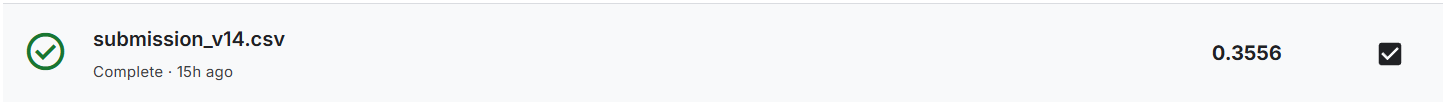

In [ ]:
submission_df = pd.read_csv('/content/submission_v14.csv')
display(submission_df)

,id,votes
0,constituency_10_1_1,14813
1,constituency_10_1_2,14360
2,constituency_10_1_3,979
3,constituency_10_1_4,244
4,constituency_10_1_5,351
...,...,...
10048,party_list_34_11_53,14
10049,party_list_34_11_54,41
10050,party_list_34_11_55,29
10051,party_list_34_11_56,43
